# Barren Plateau: Overview through Pauli-Progation

This notebook shows the phenomenon of Barren Plateaus for observables-based trainings.

## Theorem

Let the expectation value of a circuit's observable be written as a Pauli path expansion:
$$\langle O \rangle(\boldsymbol{\theta}) = \sum_{x} c_x \prod_{i \in S_x} f_{x,i}(\theta_i),
\qquad f_{x,i} \in \{\sin, \cos\}$$
where each parameter appears **at most once** per product term and
$\theta_i \sim \mathrm{Uniform}(0, 2\pi)$ independently. Then for any parameter $\theta_j$:

$$\boxed{\mathrm{Var}\!\left(\frac{\partial \langle O \rangle}{\partial \theta_j}\right)
= \sum_{x:\, j \in S_x} c_x^2 \cdot 2^{-|S_x|} = C \cdot \mathbb{E}_p[2^{-k}]}$$

where $C = \sum_{x: j \in S_x} c_x^2$, $\;k = |S_x|$, and
$p_k = A_k / C$ with $A_k = \sum_{x: |S_x|=k} c_x^2$.

### Theorem: Lower Bound of Gradient's variance
$$
\mathrm{Var}\!\left(\frac{\partial \langle O \rangle}{\partial \theta_j}\right)
=
		\;\geq\;
		\frac{|\mathcal{X}|}{p}
		\cdot \langle k \rangle \cdot 2^{-\langle k \rangle},
$$
where $|\mathcal{X}|$ is the total number of Pauli paths and
$\langle k \rangle = \frac{1}{|\mathcal{X}|}\sum_x |S_x|$ is the mean path length.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from scipy.optimize import curve_fit

from pprop.propagator import Propagator

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 14, 'figure.dpi': 120})
rng = np.random.default_rng(seed=42)

/home/samonaco/Pauli-Propagator/.venv/lib/python3.12/site-packages/pennylane/operation.py:2622: PennyLaneDeprecationWarning: Observable is deprecated and will be removed in v0.43. A generic Operator class should be used instead. If defining an Operator, set the is_hermitian property to True. If checking if an Operator is Hermitian, check the is_hermitian property. 
  warnings.warn(


In [2]:
def make_he_ansatz(n_qubits: int, n_layers: int):
    """
    Hardware-efficient ansatz: d layers of (RY on each qubit) + (CNOT ring).
    Observable: Z on qubit 0.  Total parameters: n * d.
    """
    def ansatz(params):
        idx = 0
        for _ in range(n_layers):
            for q in range(n_qubits):
                qml.RY(params[idx], wires=q)
                idx += 1
            for q in range(n_qubits):
                qml.CNOT(wires=[q, (q + 1) % n_qubits])
            qml.Barrier()
        return [qml.expval(qml.PauliZ(0))]
    return ansatz

In [3]:
example_num_qubits = 4
example_num_layers = 2

print("Hardware-efficient ansatz:")
print(f" > num_qubits: {example_num_qubits}")
print(f" > num_layers: {example_num_layers}\n")
print(qml.draw(make_he_ansatz(example_num_qubits, example_num_layers))(qml.numpy.arange(100)))

Hardware-efficient ansatz:
 > num_qubits: 4
 > num_layers: 2

0: ──RY(0.00)─╭●───────╭X──||──RY(4.00)─╭●───────╭X──||─┤  <Z>
1: ──RY(1.00)─╰X─╭●────│───||──RY(5.00)─╰X─╭●────│───||─┤     
2: ──RY(2.00)────╰X─╭●─│───||──RY(6.00)────╰X─╭●─│───||─┤     
3: ──RY(3.00)───────╰X─╰●──||──RY(7.00)───────╰X─╰●──||─┤     


In [4]:
def exact_gradient_variance(prop, param_idx):
    """
    Exact gradient variance for parameter param_idx via the theorem:
        Var(dL/d theta_j) = sum_{x: j in S_x} c_x^2 * 2^{-|S_x|}
    Computed directly from prop.exprs[0] in O(|exprs|). No sampling.
    """
    var = 0.0
    for coeff, sin_idx, cos_idx in prop.exprs[0]:
        S_x = list(sin_idx) + list(cos_idx)
        if param_idx in S_x:
            var += coeff**2 * 2**(-len(S_x))
    return var

def get_frequencies(prop):
    """
    Exact gradient variance for parameter param_idx via the theorem:
        Var(dL/d theta_j) = sum_{x: j in S_x} c_x^2 * 2^{-|S_x|}
    Computed directly from prop.exprs[0] in O(|exprs|). No sampling.
    """
    var = []
    for coeff, sin_idx, cos_idx in prop.exprs[0]:
        S_x = list(sin_idx) + list(cos_idx)
        var.append(len(S_x))
    return var


def exact_gradient_variance_mean(prop):
    """
    Exact variance averaged over all parameter indices.
    """
    var_per_param = np.array([
        exact_gradient_variance(prop, j)
        for j in range(prop.num_params)
    ])
    return float(np.mean(var_per_param)), var_per_param

def sampled_gradient_variance(prop, n_samples=500):
    """
    Estimate the gradient variance by sampling random parameter vectors
    and computing exact analytic gradients via eval_and_grad.
    """
    rng = np.random.default_rng()
    all_grads = np.empty((n_samples, prop.num_params))
    for i in range(n_samples):
        theta = rng.uniform(0, 2 * np.pi, size=prop.num_params)
        _, grads = prop.eval_and_grad(theta)
        all_grads[i] = grads[0]

    var_per_param = np.var(all_grads, axis=0)
    return float(np.mean(var_per_param)), float(np.std(var_per_param))

## 3. Sweep over Qubit Number $n$

In [5]:
N_QUBITS_RANGE = [2, 3, 4, 5, 6, 7, 8]
N_LAYERS       = 3

print(f"Sweeping n = {N_QUBITS_RANGE},  d = {N_LAYERS}\n")
print(f"{'n':>4} | {'Exact Var':>14} | {'log2(Var)':>10} | {'log2(Var)':>10}")
print("-" * 50)

exact_vars_n = []
exact_per_param_n = []
freqs_n = []
params_n = []
lower_bounds_n = []
samples_vars_mean_n = []
samples_vars_std_n = []

for n in N_QUBITS_RANGE:
    prop = Propagator(make_he_ansatz(n, N_LAYERS))
    prop.propagate()
    mean_var, var_pp = exact_gradient_variance_mean(prop)
    exact_vars_n.append(mean_var)
    exact_per_param_n.append(var_pp)
    freqs_n.append(get_frequencies(prop))
    params_n.append(prop.num_params)
    
    sampled_out = sampled_gradient_variance(prop)
    samples_vars_mean_n.append(sampled_out[0])
    samples_vars_std_n.append(sampled_out[1])
    
    lower_bound = len(freqs_n[-1]) / params_n[-1] * np.mean(freqs_n[-1]) * 2**(-np.mean(freqs_n[-1]))
    lower_bounds_n.append(lower_bound)
    print(f"{n:>4} | {mean_var:>14.6e} | {np.log2(mean_var):>10.3f} | {lower_bound:>14.6e}")

exact_vars_n = np.array(exact_vars_n)

Sweeping n = [2, 3, 4, 5, 6, 7, 8],  d = 3

   n |      Exact Var |  log2(Var) |  log2(Var)
--------------------------------------------------
   2 |   2.135417e-01 |     -2.227 |   2.083333e-01
   3 |   1.111111e-01 |     -3.170 |   1.080302e-01
   4 |   6.066895e-02 |     -4.043 |   4.759678e-02
   5 |   3.058268e-02 |     -5.031 |   2.115912e-02
   6 |   1.572673e-02 |     -5.991 |   1.045374e-02
   7 |   8.843921e-03 |     -6.821 |   4.762510e-03
   8 |   4.988069e-03 |     -7.647 |   2.339221e-03


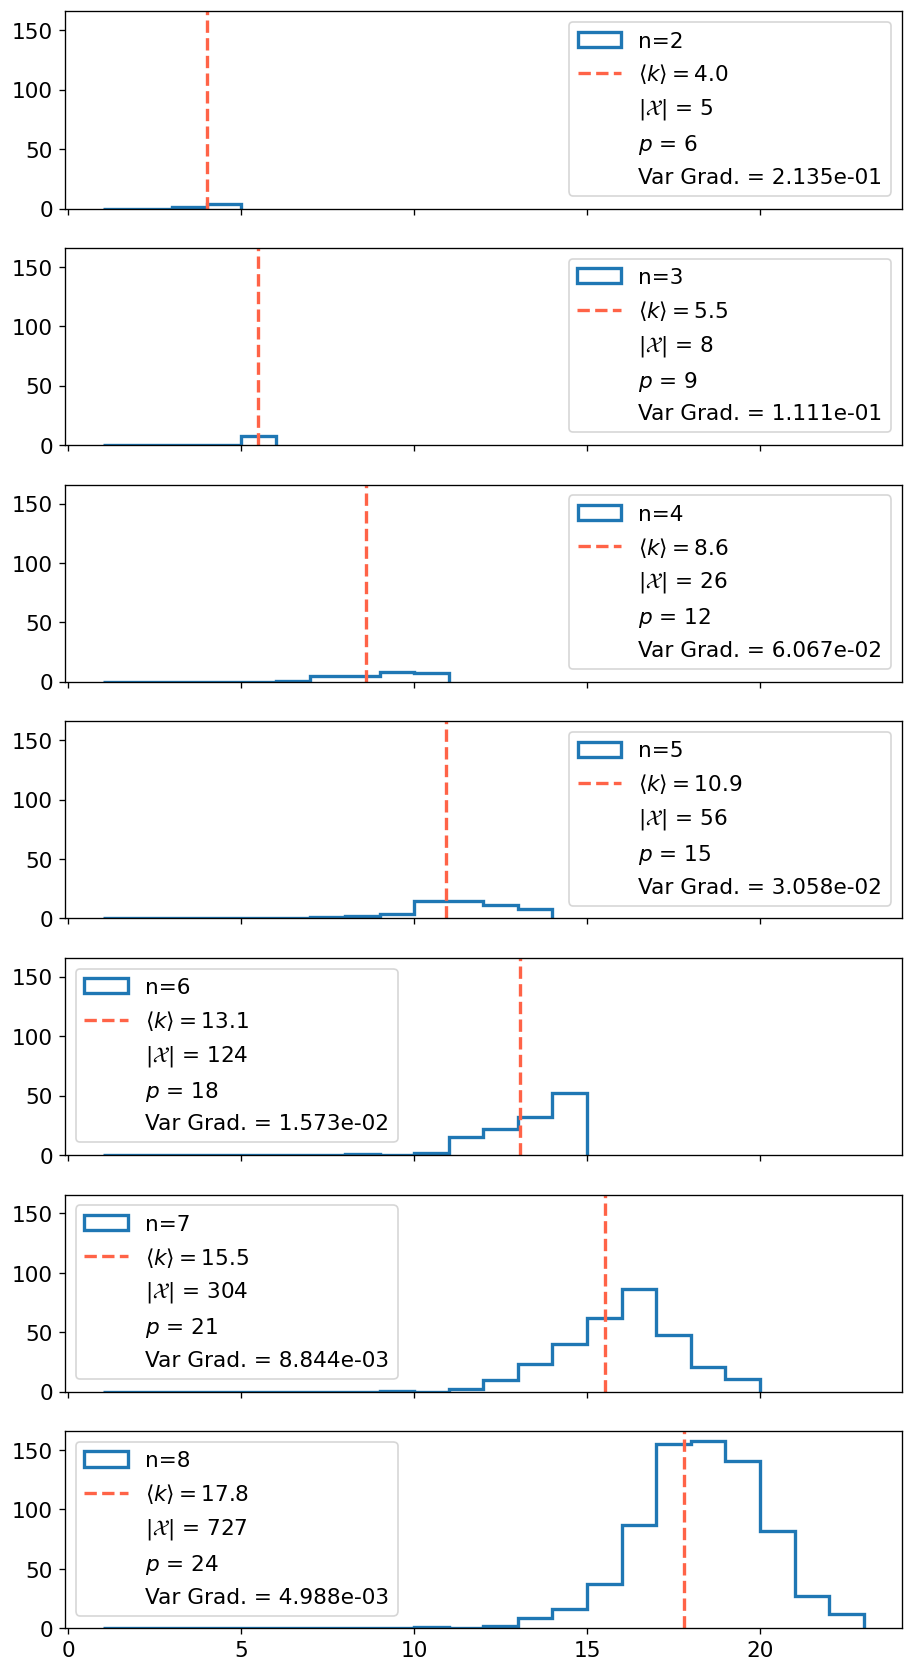

In [6]:
fig, axes = plt.subplots(len(N_QUBITS_RANGE), 1, figsize=(9, 2.5*len(N_QUBITS_RANGE)), sharex=True, sharey=True)
for i, n in enumerate(N_QUBITS_RANGE):

    axes[i].hist(freqs_n[i], bins=range(1, max(freqs_n[i])+1), histtype='step', lw=2, label=f'n={n}')
    axes[i].axvline(np.mean(freqs_n[i]), color='tomato', lw=2, ls='--', label=rf'$\langle k\rangle = {np.mean(freqs_n[i]):.1f}$')
    axes[i].plot([], [], color='white', label=rf'$|\mathcal{{X}}|$ = {len(freqs_n[i])}')
    axes[i].plot([], [], color='white', label=rf'$p$ = {params_n[i]}')
    axes[i].plot([], [], color='white', label=f'Var Grad. = {exact_vars_n[i]:.3e}')
    axes[i].legend()

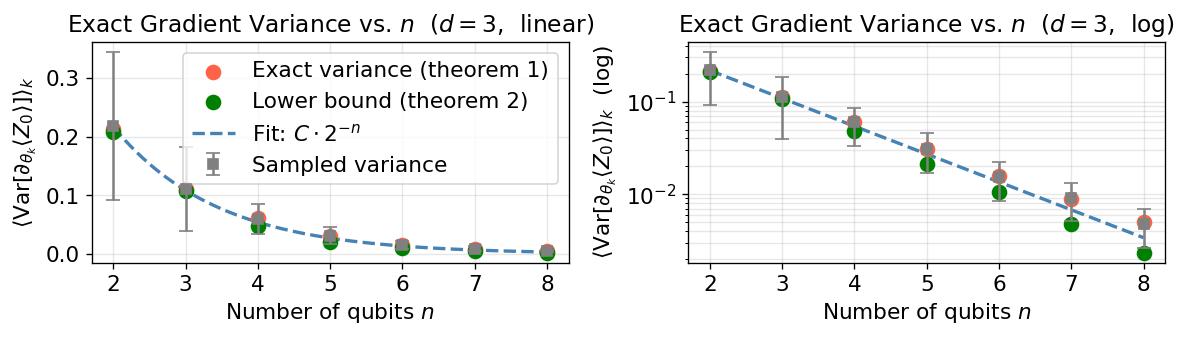

In [7]:
def exp_decay(n, C):
    return C * 2**(-np.asarray(n, dtype=float))

n_arr  = np.array(N_QUBITS_RANGE, dtype=float)
n_fine = np.linspace(n_arr[0], n_arr[-1], 300)

C_fit, _ = curve_fit(exp_decay, n_arr, exact_vars_n, p0=[3,])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for ax, yscale in zip(axes, ['linear', 'log']):
    ax.scatter(N_QUBITS_RANGE, exact_vars_n, color='tomato', s=70, zorder=5,
               label='Exact variance (theorem 1)')
    ax.scatter(N_QUBITS_RANGE, lower_bounds_n, color='green', s=70, zorder=5,
               label='Lower bound (theorem 2)')
    ax.errorbar(N_QUBITS_RANGE, samples_vars_mean_n, yerr=samples_vars_std_n,
            fmt='s', color='gray', capsize=4, lw=1.5, zorder=5,
            label='Sampled variance')
    ax.plot(n_fine, exp_decay(n_fine, C_fit), color='steelblue', lw=2, ls='--',
            label=f'Fit: $C \\cdot {2}^{{-n}}$')
    ax.set_yscale(yscale)
    ax.set_xlabel('Number of qubits $n$')
    ax.set_ylabel(
        r'$\langle\mathrm{Var}[\partial_{\theta_k}\langle Z_0\rangle]\rangle_k$'
        + ('' if yscale == 'linear' else '  (log)'))
    ax.set_title(f'Exact Gradient Variance vs. $n$  ($d={N_LAYERS}$,  {yscale})')
    if yscale == 'linear':
        ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

The exact formula (red) and Monte Carlo estimates (gray, error bars show std over parameters)
agree at every $n$, confirming Theorem 1 numerically.
Both decay exponentially with $n$, consistent with the barren plateau scaling $\overline{\mathrm{Var}} \sim b^{-n}$.
The green points show the lower bound $\frac{|\mathcal{X}|}{p} \cdot \langle k \rangle \cdot 2^{-\langle k \rangle}$
from Theorem 2, which lies below the exact variance at every $n$.

In [8]:
N_LAYERS_RANGE = [1, 2, 3, 4, 5, 6, 7, 8]
N_QUBITS       = 3

print(f"Sweeping n = {N_QUBITS_RANGE},  d = {N_LAYERS}\n")
print(f"{'n':>4} | {'Exact Var':>14} | {'log2(Var)':>10} | {'log2(Var)':>10}")
print("-" * 50)

exact_vars_d = []
exact_per_param_d = []
freqs_d = []
params_d = []
lower_bounds_d = []
samples_vars_mean_d = []
samples_vars_std_d = []

for d in N_LAYERS_RANGE:
    prop = Propagator(make_he_ansatz(N_QUBITS, d))
    prop.propagate()
    mean_var, var_pp = exact_gradient_variance_mean(prop)
    exact_vars_d.append(mean_var)
    exact_per_param_d.append(var_pp)
    freqs_d.append(get_frequencies(prop))
    params_d.append(prop.num_params)
    
    sampled_out = sampled_gradient_variance(prop)
    samples_vars_mean_d.append(sampled_out[0])
    samples_vars_std_d.append(sampled_out[1])
    
    lower_bound = len(freqs_d[-1]) / params_d[-1] * np.mean(freqs_d[-1]) * 2**(-np.mean(freqs_d[-1]))
    lower_bounds_d.append(lower_bound)
    print(f"{n:>4} | {mean_var:>14.6e} | {np.log2(mean_var):>10.3f} | {lower_bound:>14.6e}")

exact_vars_d = np.array(exact_vars_d)

Sweeping n = [2, 3, 4, 5, 6, 7, 8],  d = 3

   n |      Exact Var |  log2(Var) |  log2(Var)
--------------------------------------------------
   8 |   1.666667e-01 |     -2.585 |   1.666667e-01
   8 |   1.250000e-01 |     -3.000 |   1.250000e-01
   8 |   1.111111e-01 |     -3.170 |   1.080302e-01
   8 |   1.093750e-01 |     -3.193 |   8.945571e-02
   8 |   1.208333e-01 |     -3.049 |   8.265496e-02
   8 |   1.180556e-01 |     -3.082 |   6.109172e-02
   8 |   1.160714e-01 |     -3.107 |   4.481513e-02
   8 |   1.155599e-01 |     -3.113 |   3.211673e-02


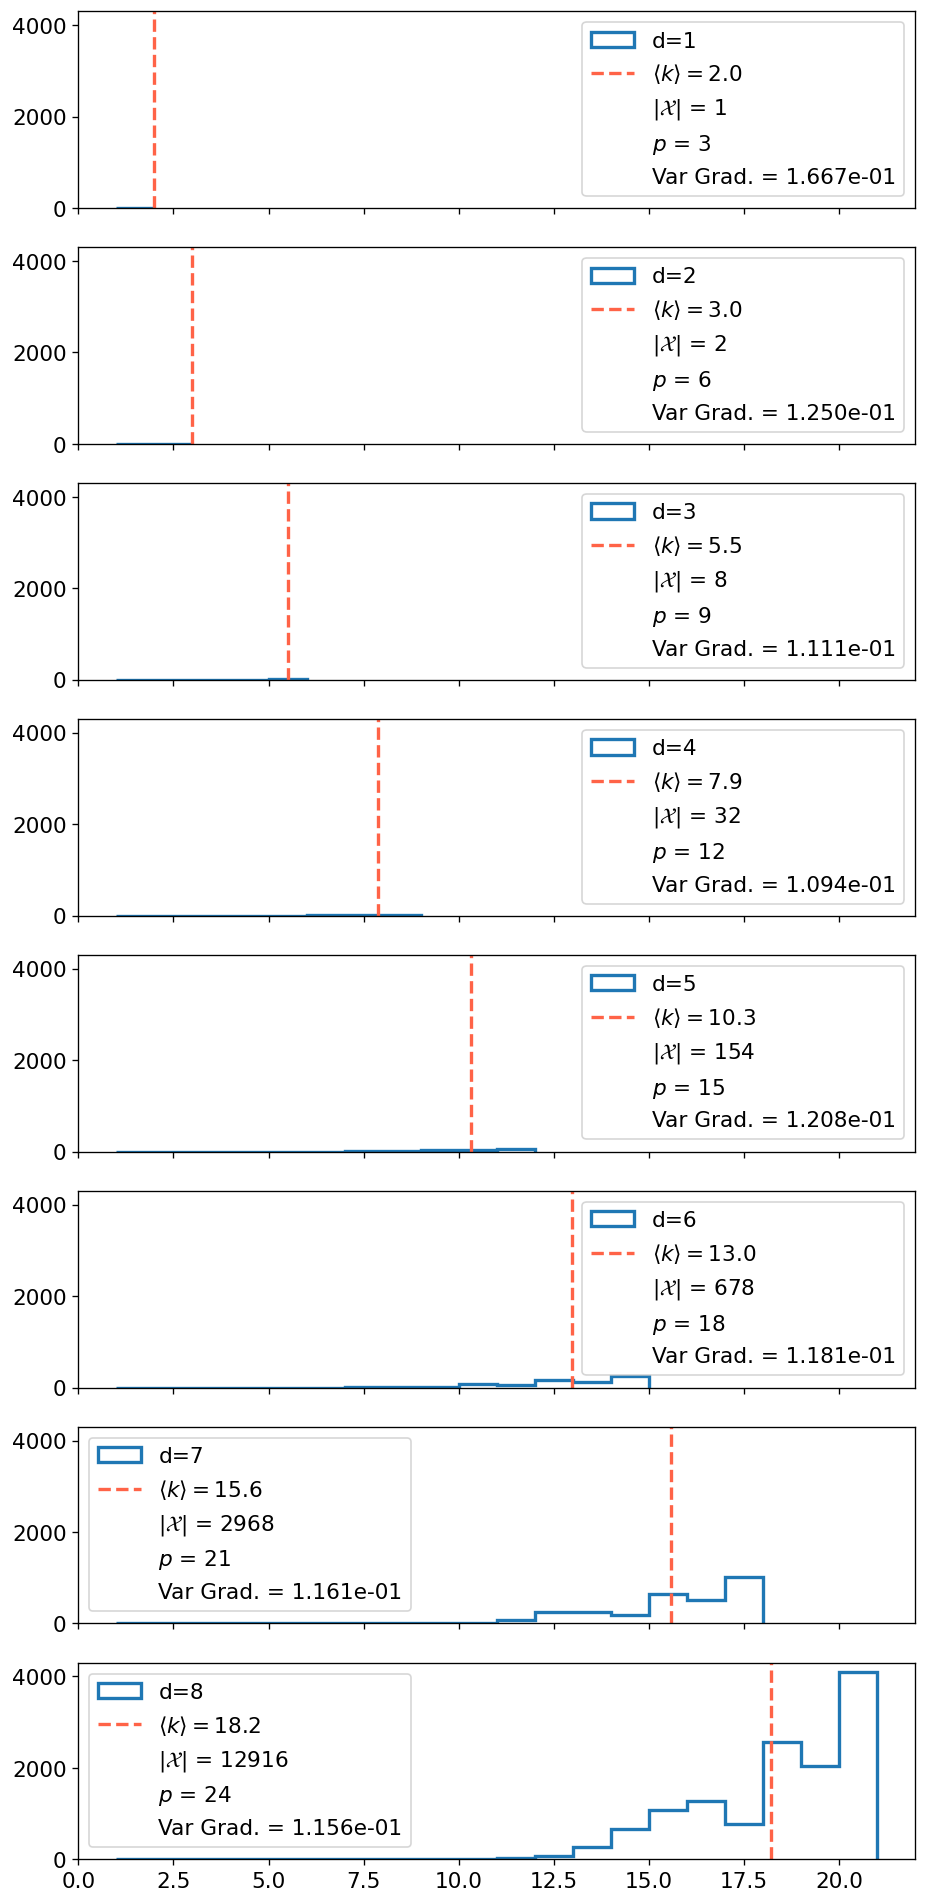

In [9]:
fig, axes = plt.subplots(len(N_LAYERS_RANGE), 1, figsize=(9, 2.5*len(N_LAYERS_RANGE)), sharex=True, sharey=True)
for i, d in enumerate(N_LAYERS_RANGE):

    axes[i].hist(freqs_d[i], bins=range(1, max(freqs_d[i])+1), histtype='step', lw=2, label=f'd={d}')
    axes[i].axvline(np.mean(freqs_d[i]), color='tomato', lw=2, ls='--', label=rf'$\langle k\rangle = {np.mean(freqs_d[i]):.1f}$')
    axes[i].plot([], [], color='white', label=rf'$|\mathcal{{X}}|$ = {len(freqs_d[i])}')
    axes[i].plot([], [], color='white', label=rf'$p$ = {params_d[i]}')
    axes[i].plot([], [], color='white', label=f'Var Grad. = {exact_vars_d[i]:.3e}')
    axes[i].legend()

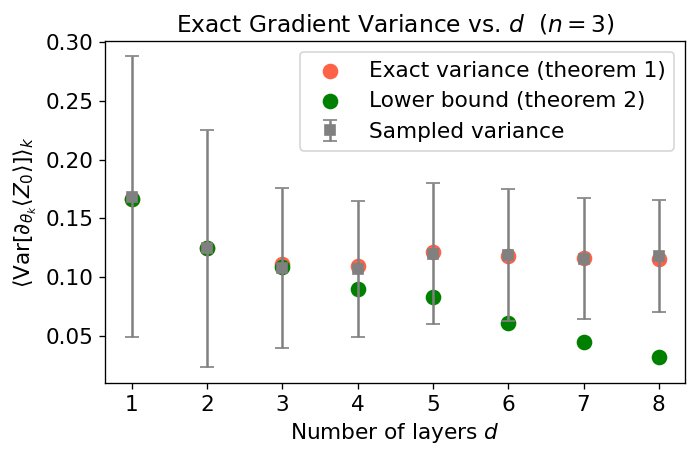

In [10]:
d_arr  = np.array(N_LAYERS_RANGE, dtype=float)
d_fine = np.linspace(n_arr[0], n_arr[-1], 300)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.scatter(N_LAYERS_RANGE, exact_vars_d, color='tomato', s=70, zorder=5,
           label='Exact variance (theorem 1)')
ax.scatter(N_LAYERS_RANGE, lower_bounds_d, color='green', s=70, zorder=5,
           label='Lower bound (theorem 2)')
ax.errorbar(N_LAYERS_RANGE, samples_vars_mean_d, yerr=samples_vars_std_d,
        fmt='s', color='gray', capsize=4, lw=1.5, zorder=5,
        label='Sampled variance')
ax.set_xlabel('Number of layers $d$')
ax.set_ylabel(
    r'$\langle\mathrm{Var}[\partial_{\theta_k}\langle Z_0\rangle]\rangle_k$' )
ax.set_title(f'Exact Gradient Variance vs. $d$  ($n={N_QUBITS}$)')
ax.legend()

plt.tight_layout()
plt.show()